In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
with open(
    "/content/drive/MyDrive/PK-SubCpmk 3/queries.json",
    "r",
    encoding="utf-8"
) as f:
    queries = json.load(f)

len(queries)

10

In [6]:
retrieval_df = pd.read_csv(
    "/content/drive/MyDrive/PK-SubCpmk 3/retrieval_results.csv"
)

retrieval_df.head()

,query_id,query,top_5_case_ids
0,1,penipuan jual beli sepeda motor,"[4, 1, 44, 15, 11]"
1,2,penggelapan uang perusahaan oleh karyawan,"[2, 37, 8, 6, 11]"
2,3,penipuan kendaraan bermotor,"[19, 39, 12, 11, 15]"
3,4,penipuan pengurusan warisan dan tanah,"[5, 23, 24, 43, 42]"
4,5,penipuan investasi atau kerja sama usaha,"[3, 36, 15, 8, 2]"


# retrieval metrik

In [7]:
# retrieval metrik
import ast

retrieval_df["top_5_case_ids"] = retrieval_df[
    "top_5_case_ids"
].apply(ast.literal_eval)

In [8]:
y_true = []
y_pred = []

for item in queries:

    gt = item["ground_truth_case_id"]

    row = retrieval_df[
        retrieval_df["query_id"] == item["query_id"]
    ]

    retrieved_ids = row.iloc[0]["top_5_case_ids"]

    y_true.append(1)

    if gt in retrieved_ids:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [9]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6
Precision: 1.0
Recall   : 0.6
F1 Score : 0.75


In [10]:
retrieval_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

retrieval_metrics

,Metric,Value
0,Accuracy,0.60
1,Precision,1.00
2,Recall,0.60
3,F1-Score,0.75


In [11]:
retrieval_metrics.to_csv(
    "/content/drive/MyDrive/PK-SubCpmk 3/retrieval_metrics.csv",
    index=False
)

# Case Reuse (prediction)

In [12]:
demo_df = pd.read_csv(
    "/content/drive/MyDrive/PK-SubCpmk 3/demo_comparison.csv"
)

demo_df.head()

,query_id,query,ground_truth_case_id,predicted_solution,actual_solution
0,1,penipuan jual beli sepeda motor,1,1. Menyatakan terdakwa MUHAMMAD IKHSAN GUNAWAN...,1. Menyatakan Terdakwa DERIN HARISTYA UKITA Bi...
1,2,penggelapan uang perusahaan oleh karyawan,2,1. Menyatakan Terdakwa MUHAMAD ISSYAK HUSEN AM...,1. Menyatakan Terdakwa MUHAMAD ISSYAK HUSEN AM...
2,3,penipuan kendaraan bermotor,4,1. Menyatakan terdakwa REZA AHMAD HANDRIYANA B...,1. Menyatakan terdakwa MUHAMMAD IKHSAN GUNAWAN...
3,4,penipuan pengurusan warisan dan tanah,5,1.\nMenyatakan Terdakwa RUDY SYARIF telah terb...,1.\nMenyatakan Terdakwa RUDY SYARIF telah terb...
4,5,penipuan investasi atau kerja sama usaha,8,1. Menyatakan Terdakwa Ardy Putra Auwy anak da...,"1. Menyatakan terdakwa Nelly Rosmawati, SE Bin..."


In [13]:
demo_df["correct"] = (
    demo_df["predicted_solution"]
    ==
    demo_df["actual_solution"]
)

prediction_accuracy = demo_df["correct"].mean()

print(
    f"Prediction Accuracy: {prediction_accuracy:.4f}"
)

Prediction Accuracy: 0.4000


In [15]:
prediction_metrics = pd.DataFrame({
    "Metric": ["Prediction Accuracy"],
    "Value": [prediction_accuracy]
})

prediction_metrics

,Metric,Value
0,Prediction Accuracy,0.4


In [16]:
prediction_metrics.to_csv(
    "/content/drive/MyDrive/PK-SubCpmk 3/prediction_metrics.csv",
    index=False
)

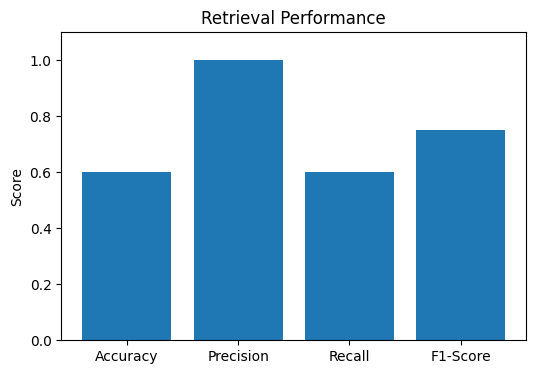

In [17]:
# visualisasi retrieval
import matplotlib.pyplot as plt

metrics = retrieval_metrics["Metric"]
values = retrieval_metrics["Value"]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Retrieval Performance")
plt.ylabel("Score")
plt.ylim(0,1.1)

plt.show()